## Questão 4

## Importanto Bibliotecas

In [1]:
import pandas as pd
import requests
from matplotlib import pyplot as plt

pd.set_option('display.max_columns', None)

## Carregando os Dados

In [2]:
def get_dolar_bruto(data_inicio, data_fim):
    """
    Obtém as cotações PTAX brutas (apenas dias úteis) via API Olinda do BCB.
    Datas esperadas no formato 'YYYY-MM-DD'.
    """
    # A API exige o formato MM-DD-YYYY para a URL
    start = pd.to_datetime(data_inicio).strftime('%m-%d-%Y')
    end = pd.to_datetime(data_fim).strftime('%m-%d-%Y')
    
    url = (
        f"https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
        f"CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?"
        f"@dataInicial='{start}'&@dataFinalCotacao='{end}'&$format=json"
    )
    
    try:
        response = requests.get(url)
        response.raise_for_status()  # Levanta erro se a conexão falhar
        
        dados = response.json()['value']
        df_dolar = pd.DataFrame(dados)
        
        # Converter a coluna de data e remover a parte da hora (PTAX é diária)
        df_dolar['dataHoraCotacao'] = pd.to_datetime(df_dolar['dataHoraCotacao']).dt.normalize()
        
        # Selecionar apenas o necessário e renomear para facilitar o merge futuro
        df_dolar = df_dolar[['dataHoraCotacao', 'cotacaoVenda']].rename(
            columns={
                'dataHoraCotacao': 'data',
                'cotacaoVenda': 'cotacao'
            }
        )
        
        df_dolar = df_dolar.sort_values('data')
        
        return df_dolar

    except Exception as e:
        print(f"Erro na requisição: {e}")
        return None

In [3]:
cotacao_dollar = get_dolar_bruto('2022-12-01', '2024-12-31')

vendas = pd.read_csv('../../datasets/vendas.csv') 

custos_importacao = pd.read_csv('../../datasets/custos_importacao.csv') 

In [4]:
cotacao_dollar.head(10)

,data,cotacao
0,2022-12-01,5.1948
1,2022-12-02,5.1974
2,2022-12-05,5.2464
3,2022-12-06,5.2396
4,2022-12-07,5.2208
5,2022-12-08,5.2091
6,2022-12-09,5.2396
7,2022-12-12,5.3066
8,2022-12-13,5.2669
9,2022-12-14,5.3406


In [5]:
vendas.head(10)

,id,client_id,product_id,qtd,total,sale_date
0,0,42,105,11,3405.00,2023-09-10
1,1,3,136,9,16873.90,2024-09-15
2,2,25,139,7,9475.30,2024-08-13
3,4,20,23,5,55893.00,2023-02-03
4,5,8,57,4,451403.90,2024-02-12
5,6,36,52,3,39056.40,2023-09-26
6,8,27,25,3,34560.05,2024-02-28
7,9,37,26,7,114932.90,2023-11-07
8,10,31,143,3,12643.55,2024-08-25
9,11,39,128,5,23254.00,2023-05-07


In [6]:
custos_importacao.head(10)

,product_id,start_date,usd_price
0,1,2016-08-10,10583.63
1,1,2018-06-15,8778.36
2,1,2018-09-25,8023.87
3,1,2019-03-19,8772.78
4,1,2020-01-17,7918.18
5,1,2020-06-17,6310.01
6,1,2021-07-02,6586.70
7,1,2022-05-16,6538.20
8,1,2023-02-28,6360.91
9,1,2023-10-17,6574.80


In [7]:
cotacao_dollar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     524 non-null    datetime64[ns]
 1   cotacao  524 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.3 KB


In [8]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   client_id   9895 non-null   int64  
 2   product_id  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   object 
dtypes: float64(1), int64(4), object(1)
memory usage: 464.0+ KB


In [9]:
custos_importacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   product_id  1260 non-null   int64  
 1   start_date  1260 non-null   object 
 2   usd_price   1260 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 29.7+ KB


## Formatando os Dados

In [10]:
vendas['sale_date'] = pd.to_datetime(vendas['sale_date'])

vendas.sort_values('sale_date', inplace=True)

In [11]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9895 entries, 1215 to 866
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          9895 non-null   int64         
 1   client_id   9895 non-null   int64         
 2   product_id  9895 non-null   int64         
 3   qtd         9895 non-null   int64         
 4   total       9895 non-null   float64       
 5   sale_date   9895 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 541.1 KB


In [12]:
custos_importacao['start_date'] = pd.to_datetime(custos_importacao['start_date'])

custos_importacao.sort_values('start_date', inplace=True)

In [13]:
custos_importacao.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1260 entries, 402 to 226
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   product_id  1260 non-null   int64         
 1   start_date  1260 non-null   datetime64[ns]
 2   usd_price   1260 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 39.4 KB


## Calculando Resultados

In [14]:
vendas_com_cotacao = pd.merge_asof(
    vendas, 
    cotacao_dollar,
    left_on='sale_date', 
    right_on='data', 
    direction='backward'
)

vendas_com_cotacao.drop(
    columns='data',
    inplace=True
)

vendas_com_cotacao.rename(
    columns={
        'cotacao': 'exchange_rate'
    },
    inplace=True
)

vendas_com_cotacao.head()

,id,client_id,product_id,qtd,total,sale_date,exchange_rate
0,1230,17,91,4,512566.80,2023-01-01,5.2177
1,2300,30,95,9,596858.40,2023-01-01,5.2177
2,3131,28,130,13,53873.00,2023-01-01,5.2177
3,4212,9,96,6,402538.75,2023-01-01,5.2177
4,4294,7,44,5,51332.30,2023-01-01,5.2177


In [15]:
vendas_com_custo = pd.merge_asof(
    vendas_com_cotacao, 
    custos_importacao, 
    left_on='sale_date', 
    right_on='start_date', 
    by='product_id', 
    direction='backward'
)

vendas_com_custo.drop(
    columns=['start_date'],
    inplace=True
)

vendas_com_custo.rename(
    columns={
        'usd_price': 'usd_unit_price',
        'total': 'total_income'
    },
    inplace=True
)

vendas_com_custo.head()

,id,client_id,product_id,qtd,total_income,sale_date,exchange_rate,usd_unit_price
0,1230,17,91,4,512566.80,2023-01-01,5.2177,26303.31
1,2300,30,95,9,596858.40,2023-01-01,5.2177,12945.63
2,3131,28,130,13,53873.00,2023-01-01,5.2177,749.89
3,4212,9,96,6,402538.75,2023-01-01,5.2177,13063.42
4,4294,7,44,5,51332.30,2023-01-01,5.2177,1963.02


In [16]:
vendas_com_custo['total_cost'] = vendas_com_custo['qtd'] * vendas_com_custo['exchange_rate'] * vendas_com_custo['usd_unit_price']

vendas_com_custo['profit'] = vendas_com_custo['total_income'] - vendas_com_custo['total_cost']

vendas_com_custo.drop(
    columns=['exchange_rate', 'usd_unit_price'],
    inplace=True
)

vendas_com_custo.head()

,id,client_id,product_id,qtd,total_income,sale_date,total_cost,profit
0,1230,17,91,4,512566.80,2023-01-01,548971.122348,-36404.322348
1,2300,30,95,9,596858.40,2023-01-01,607917.722859,-11059.322859
2,3131,28,130,13,53873.00,2023-01-01,50865.113689,3007.886311
3,4212,9,96,6,402538.75,2023-01-01,408966.039204,-6427.289204
4,4294,7,44,5,51332.30,2023-01-01,51212.247270,120.052730


In [17]:
def total_loss(series):
    loss_transactions = series[series < 0]

    return -loss_transactions.sum()

In [30]:
resultados_vendas = vendas_com_custo.groupby('product_id').agg(
    revenue= ('total_income', 'sum'),
    profit= ('profit', 'sum'),
    total_loss= ('profit', total_loss)
)

resultados_vendas['loss_pct'] = resultados_vendas['total_loss'] / resultados_vendas['revenue']

resultados_vendas.sort_values('loss_pct', ascending=False)

,revenue,profit,total_loss,loss_pct
product_id,,,,
72,63057815.65,-3.982104e+07,3.982104e+07,0.631500
83,44377440.00,-1.861429e+07,1.861429e+07,0.419454
109,328320.15,-1.020613e+05,1.020613e+05,0.310859
102,335379.20,-9.649971e+04,9.649971e+04,0.287733
136,1049801.00,-2.513898e+05,2.527528e+05,0.240763
...,...,...,...,...
113,2210235.65,5.794913e+04,2.654370e+04,0.012009
24,9471755.80,5.650377e+05,7.234989e+04,0.007638
13,3774383.00,2.155089e+05,2.681163e+04,0.007104


In [27]:
resultados_vendas.sort_values('profit')

,revenue,profit,total_loss,loss_pct
product_id,,,,
72,63057815.65,-3.982104e+07,3.982104e+07,0.631500
83,44377440.00,-1.861429e+07,1.861429e+07,0.419454
74,59764356.15,-6.349379e+06,6.716610e+06,0.112385
71,81567066.65,-5.798031e+06,6.070816e+06,0.074427
55,61224375.00,-5.368318e+06,5.371141e+06,0.087729
...,...,...,...,...
24,9471755.80,5.650377e+05,7.234989e+04,0.007638
39,15493523.15,8.133965e+05,2.183397e+05,0.014092
76,83539339.40,1.167348e+06,1.508559e+06,0.018058


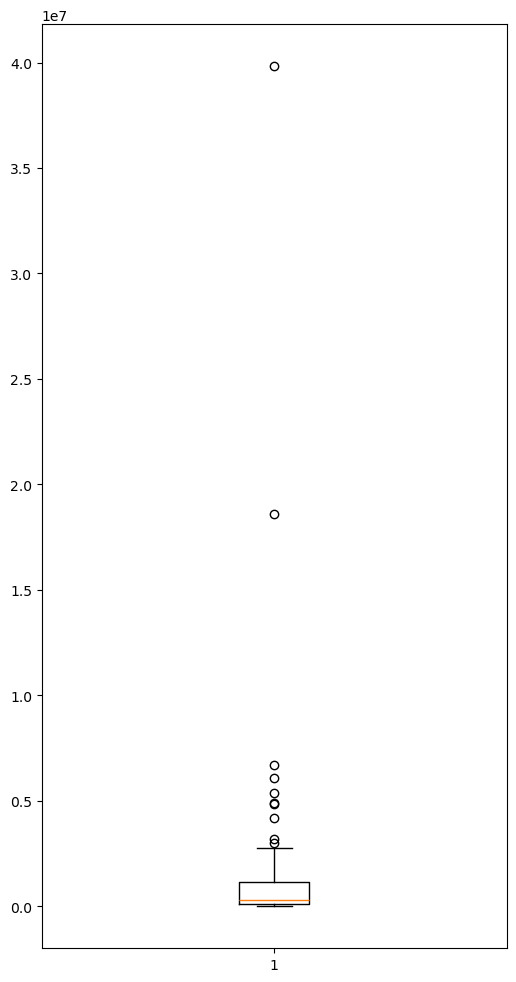

In [22]:
plt.figure(figsize=(6,12))

plt.boxplot(
    resultados_vendas['total_loss']
)

plt.show()